# Comparaison de tous les modèles

Ce notebook charge automatiquement **tous** les runs disponibles (sweeps + runs individuels) et les compare.

```bash
scp -r ivars-25@gpu-gw.enst.fr:~/Data-Challenge-Telecom-Paris-Face-Occlusion/data/submissions/ data/
```

In [1]:
import os, sys, json, glob, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

if "__vsc_ipynb_file__" in dir():
    PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)))
else:
    PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
print(f"Working directory: {os.getcwd()}")

CKPT_ROOT = "data/submissions/checkpoints"
%matplotlib inline

Working directory: /home/leo/Data_Challenge_Telecom/Data-Challenge-Telecom-Paris-Face-Occlusion


## 1. Découverte automatique de tous les runs

In [ ]:
def load_run(history_path):
    """Load a run from its history.json, return dict or None if duplicate."""
    with open(history_path) as f:
        h = json.load(f)
    best_idx = int(np.argmin(h["val_score"]))
    return {
        "history": h,
        "best_epoch": h["epoch"][best_idx],
        "best_score": h["val_score"][best_idx],
        "best_err_f": h["err_f"][best_idx],
        "best_err_m": h["err_m"][best_idx],
        "best_gap": abs(h["err_f"][best_idx] - h["err_m"][best_idx]),
        "num_epochs": len(h["epoch"]),
    }

def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

# --- Collect all runs (no dedup) ---
all_runs = []

for history_path in sorted(glob.glob(os.path.join(CKPT_ROOT, "**", "history*.json"), recursive=True)):
    print(f"  Found: {history_path}")
    
    run_dir = os.path.dirname(history_path)
    rel = os.path.relpath(run_dir, CKPT_ROOT)
    
    # Determine source type and label
    parts = rel.split(os.sep)
    basename = os.path.basename(history_path).replace("history", "").replace(".json", "").strip("_")
    fold_suffix = f" fold{basename}" if basename else ""

    if "lambda_" in rel:
        sweep_name = parts[0]
        lam = parts[1].replace("lambda_", "")
        source = "sweep_lambda"
        label = f"{sweep_name.replace('sweep_', 'S')} λ={lam}"
        group = sweep_name
    elif parts[0].startswith("sweep_mf_"):
        sweep_name = parts[0]
        mf = parts[1].replace("mf_", "") if len(parts) > 1 else "?"
        source = "sweep_mf"
        label = f"{sweep_name.replace('sweep_mf_', 'MF')} mf={mf}{fold_suffix}"
        group = sweep_name
    elif parts[0].startswith("kfold_"):
        source = "kfold"
        label = f"{parts[0].replace('kfold_', 'K')}{fold_suffix}"
        group = parts[0]
    elif parts[0].startswith("ensemble_bb_"):
        source = "ensemble_bb"
        backbone = parts[1] if len(parts) > 1 else "?"
        label = f"ens {backbone.split('.')[0]}{fold_suffix}"
        group = parts[0]
    elif parts[0].startswith("run_"):
        source = "run"
        label = parts[0].replace("run_", "R") + fold_suffix
        group = parts[0]
    else:
        source = "other"
        label = rel + fold_suffix
        group = parts[0]
    
    run_data = load_run(history_path)
    run_data.update({
        "dir": run_dir,
        "source": source,
        "label": label,
        "group": group,
    })
    all_runs.append(run_data)

df = pd.DataFrame([{k: v for k, v in r.items() if k != "history"} for r in all_runs])
df = df.sort_values("best_score").reset_index(drop=True)
print(f"{len(all_runs)} runs trouvés")
print(f"Sources: {df['source'].value_counts().to_dict()}")
df[["label", "source", "best_score", "best_err_f", "best_err_m", "best_gap", "best_epoch", "num_epochs"]]

12 runs uniques trouvés (doublons ignorés)
Sources: {'sweep_lambda': 5, 'sweep_mf': 5, 'other': 1, 'ensemble_bb': 1}


,label,source,best_score,best_err_f,best_err_m,best_gap,best_epoch,num_epochs
0,latest,other,0.001187,0.000681,0.001019,0.000338,21,28
1,S20260604_143401 λ=0.25,sweep_lambda,0.001197,0.000688,0.001028,0.000339,22,29
2,S20260604_143401 λ=1.0,sweep_lambda,0.001208,0.000788,0.001068,0.000280,22,29
3,S20260604_143401 λ=0.5,sweep_lambda,0.001240,0.000711,0.001064,0.000353,20,27
4,S20260604_143401 λ=2.0,sweep_lambda,0.001312,0.000907,0.001177,0.000269,30,30
5,S20260604_143401 λ=5.0,sweep_lambda,0.001340,0.001292,0.001324,0.000032,25,30
6,ens eva02_base_patch14_224_mim_in22k,ensemble_bb,0.001479,0.000767,0.001242,0.000475,12,19
7,MF20260609_114514 mf=3.0 foldfold0,sweep_mf,0.001657,0.001070,0.001461,0.000391,12,19
8,MF20260609_085551 mf=2.0 foldfold0,sweep_mf,0.001790,0.001088,0.001556,0.000468,12,19
9,MF20260609_064622 mf=1.5 foldfold0,sweep_mf,0.001837,0.000788,0.001487,0.000699,10,17


## 2. Classement global

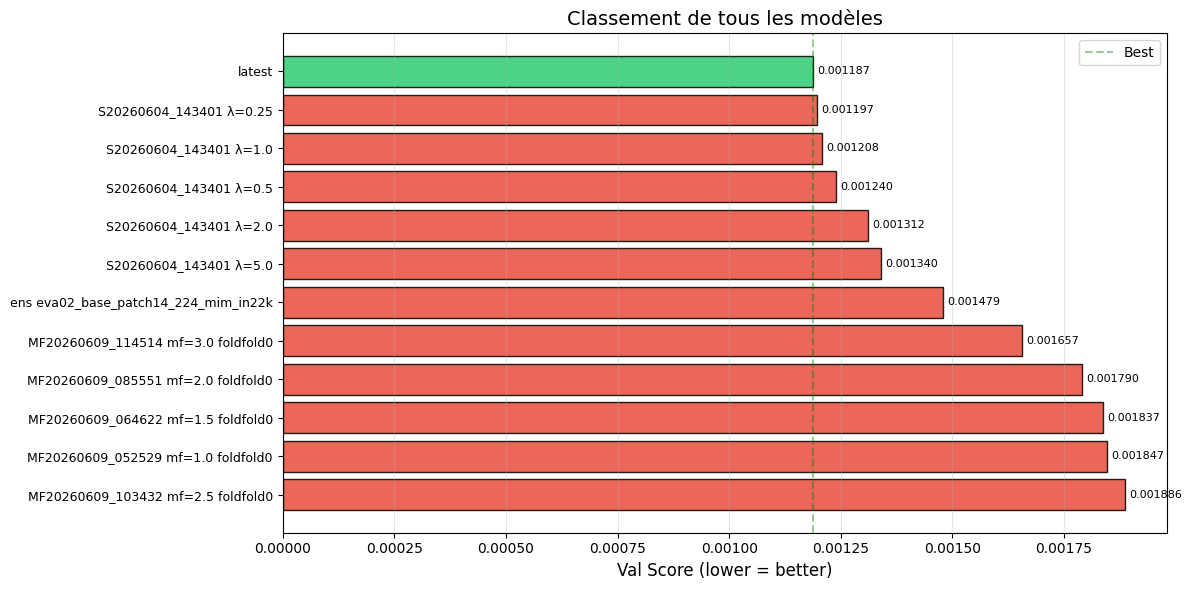


🏆 Meilleur modèle : latest (score=0.001187, epoch=21)


In [3]:
# Bar chart horizontal trié par score
df_sorted = df.sort_values("best_score", ascending=True).reset_index(drop=True)
colors = ["#2ecc71" if i == 0 else ("#3498db" if row["source"] == "sweep" else "#e74c3c")
          for i, (_, row) in enumerate(df_sorted.iterrows())]

fig, ax = plt.subplots(figsize=(12, max(4, len(df_sorted) * 0.5)))
bars = ax.barh(range(len(df_sorted)), df_sorted["best_score"], color=colors, edgecolor="black", alpha=0.85)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted["label"], fontsize=9)
ax.set_xlabel("Val Score (lower = better)", fontsize=12)
ax.set_title("Classement de tous les modèles", fontsize=14)
ax.invert_yaxis()

# Annotations
for i, (_, row) in enumerate(df_sorted.iterrows()):
    ax.text(row["best_score"] + df_sorted["best_score"].max() * 0.005, i,
            f"{row['best_score']:.6f}", va="center", fontsize=8)

ax.axvline(df_sorted["best_score"].iloc[0], color="green", linestyle="--", alpha=0.4, label="Best")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

best = df_sorted.iloc[0]
print(f"\n🏆 Meilleur modèle : {best['label']} (score={best['best_score']:.6f}, epoch={int(best['best_epoch'])})")

## 3. Décomposition Err_F / Err_M / Gap

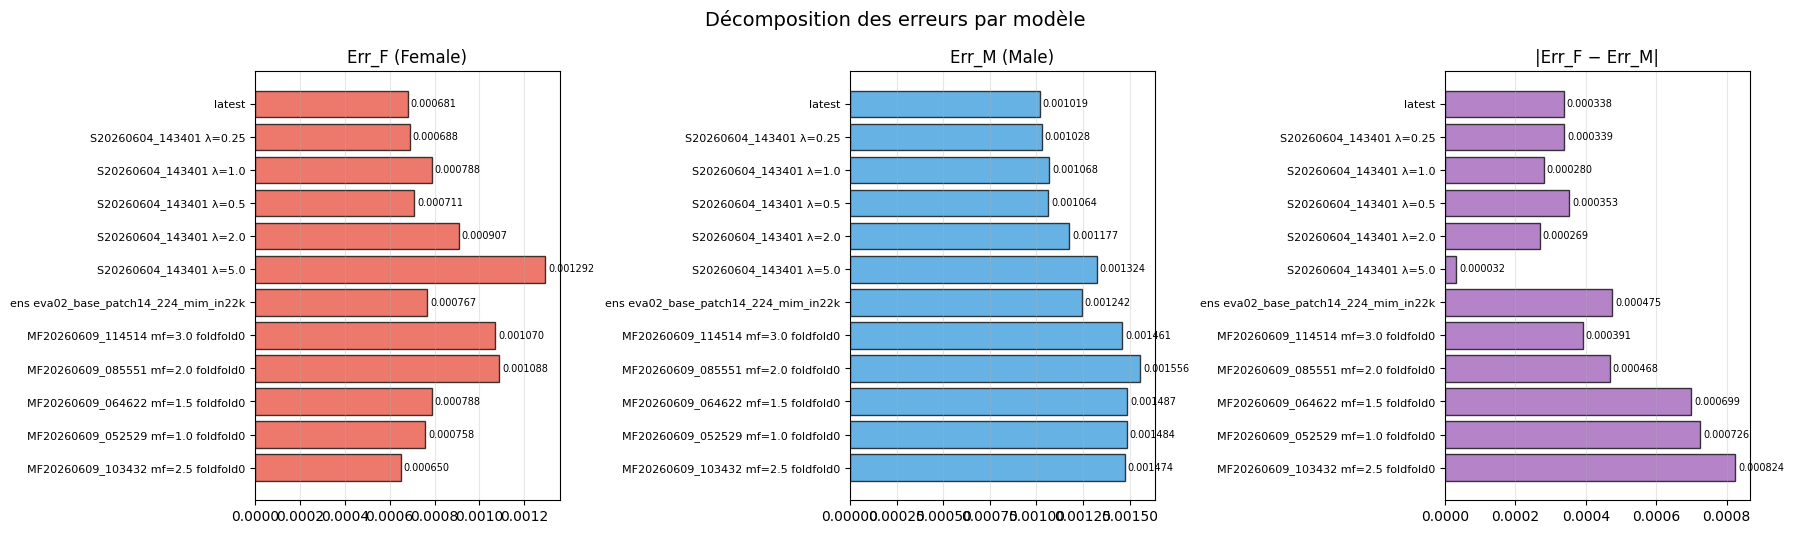

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, max(4, len(df_sorted) * 0.45)))

for ax, col, title, color in [
    (axes[0], "best_err_f", "Err_F (Female)", "#e74c3c"),
    (axes[1], "best_err_m", "Err_M (Male)", "#3498db"),
    (axes[2], "best_gap", "|Err_F − Err_M|", "#9b59b6"),
]:
    ax.barh(range(len(df_sorted)), df_sorted[col], color=color, alpha=0.75, edgecolor="black")
    ax.set_yticks(range(len(df_sorted)))
    ax.set_yticklabels(df_sorted["label"], fontsize=8)
    ax.set_title(title, fontsize=12)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    for i, val in enumerate(df_sorted[col]):
        ax.text(val + df_sorted[col].max() * 0.01, i, f"{val:.6f}", va="center", fontsize=7)

plt.suptitle("Décomposition des erreurs par modèle", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Trade-off Accuracy vs Fairness (tous les modèles)

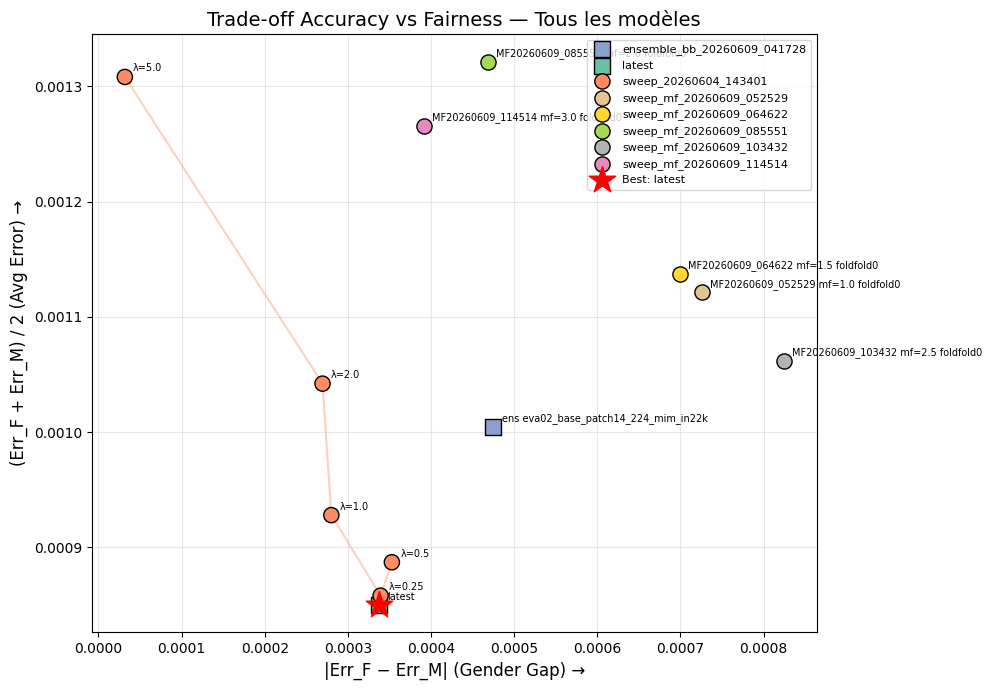

In [5]:
df["avg_err"] = (df["best_err_f"] + df["best_err_m"]) / 2

# Color by group
groups = df["group"].unique()
group_colors = {g: cm.Set2(i / max(1, len(groups) - 1)) for i, g in enumerate(groups)}

fig, ax = plt.subplots(figsize=(10, 7))

for group_name, gdf in df.groupby("group"):
    color = group_colors[group_name]
    marker = "o" if "sweep" in group_name else "s"
    ax.scatter(gdf["best_gap"], gdf["avg_err"], c=[color]*len(gdf),
              s=120, edgecolors="black", zorder=5, marker=marker, label=group_name)
    # Connect sweep points with a line
    if len(gdf) > 1:
        gdf_s = gdf.sort_values("best_gap")
        ax.plot(gdf_s["best_gap"], gdf_s["avg_err"], color=color, alpha=0.4, zorder=1)

for _, row in df.iterrows():
    ax.annotate(row["label"].split(" ")[-1] if "λ" in row["label"] else row["label"],
               (row["best_gap"], row["avg_err"]),
               textcoords="offset points", xytext=(6, 4), fontsize=7)

# Highlight best
best_row = df.loc[df["best_score"].idxmin()]
ax.scatter(best_row["best_gap"], best_row["avg_err"],
           marker="*", s=400, color="red", zorder=10, label=f"Best: {best_row['label']}")

ax.set_xlabel("|Err_F − Err_M| (Gender Gap) →", fontsize=12)
ax.set_ylabel("(Err_F + Err_M) / 2 (Avg Error) →", fontsize=12)
ax.set_title("Trade-off Accuracy vs Fairness — Tous les modèles", fontsize=14)
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Courbes d'entraînement par groupe

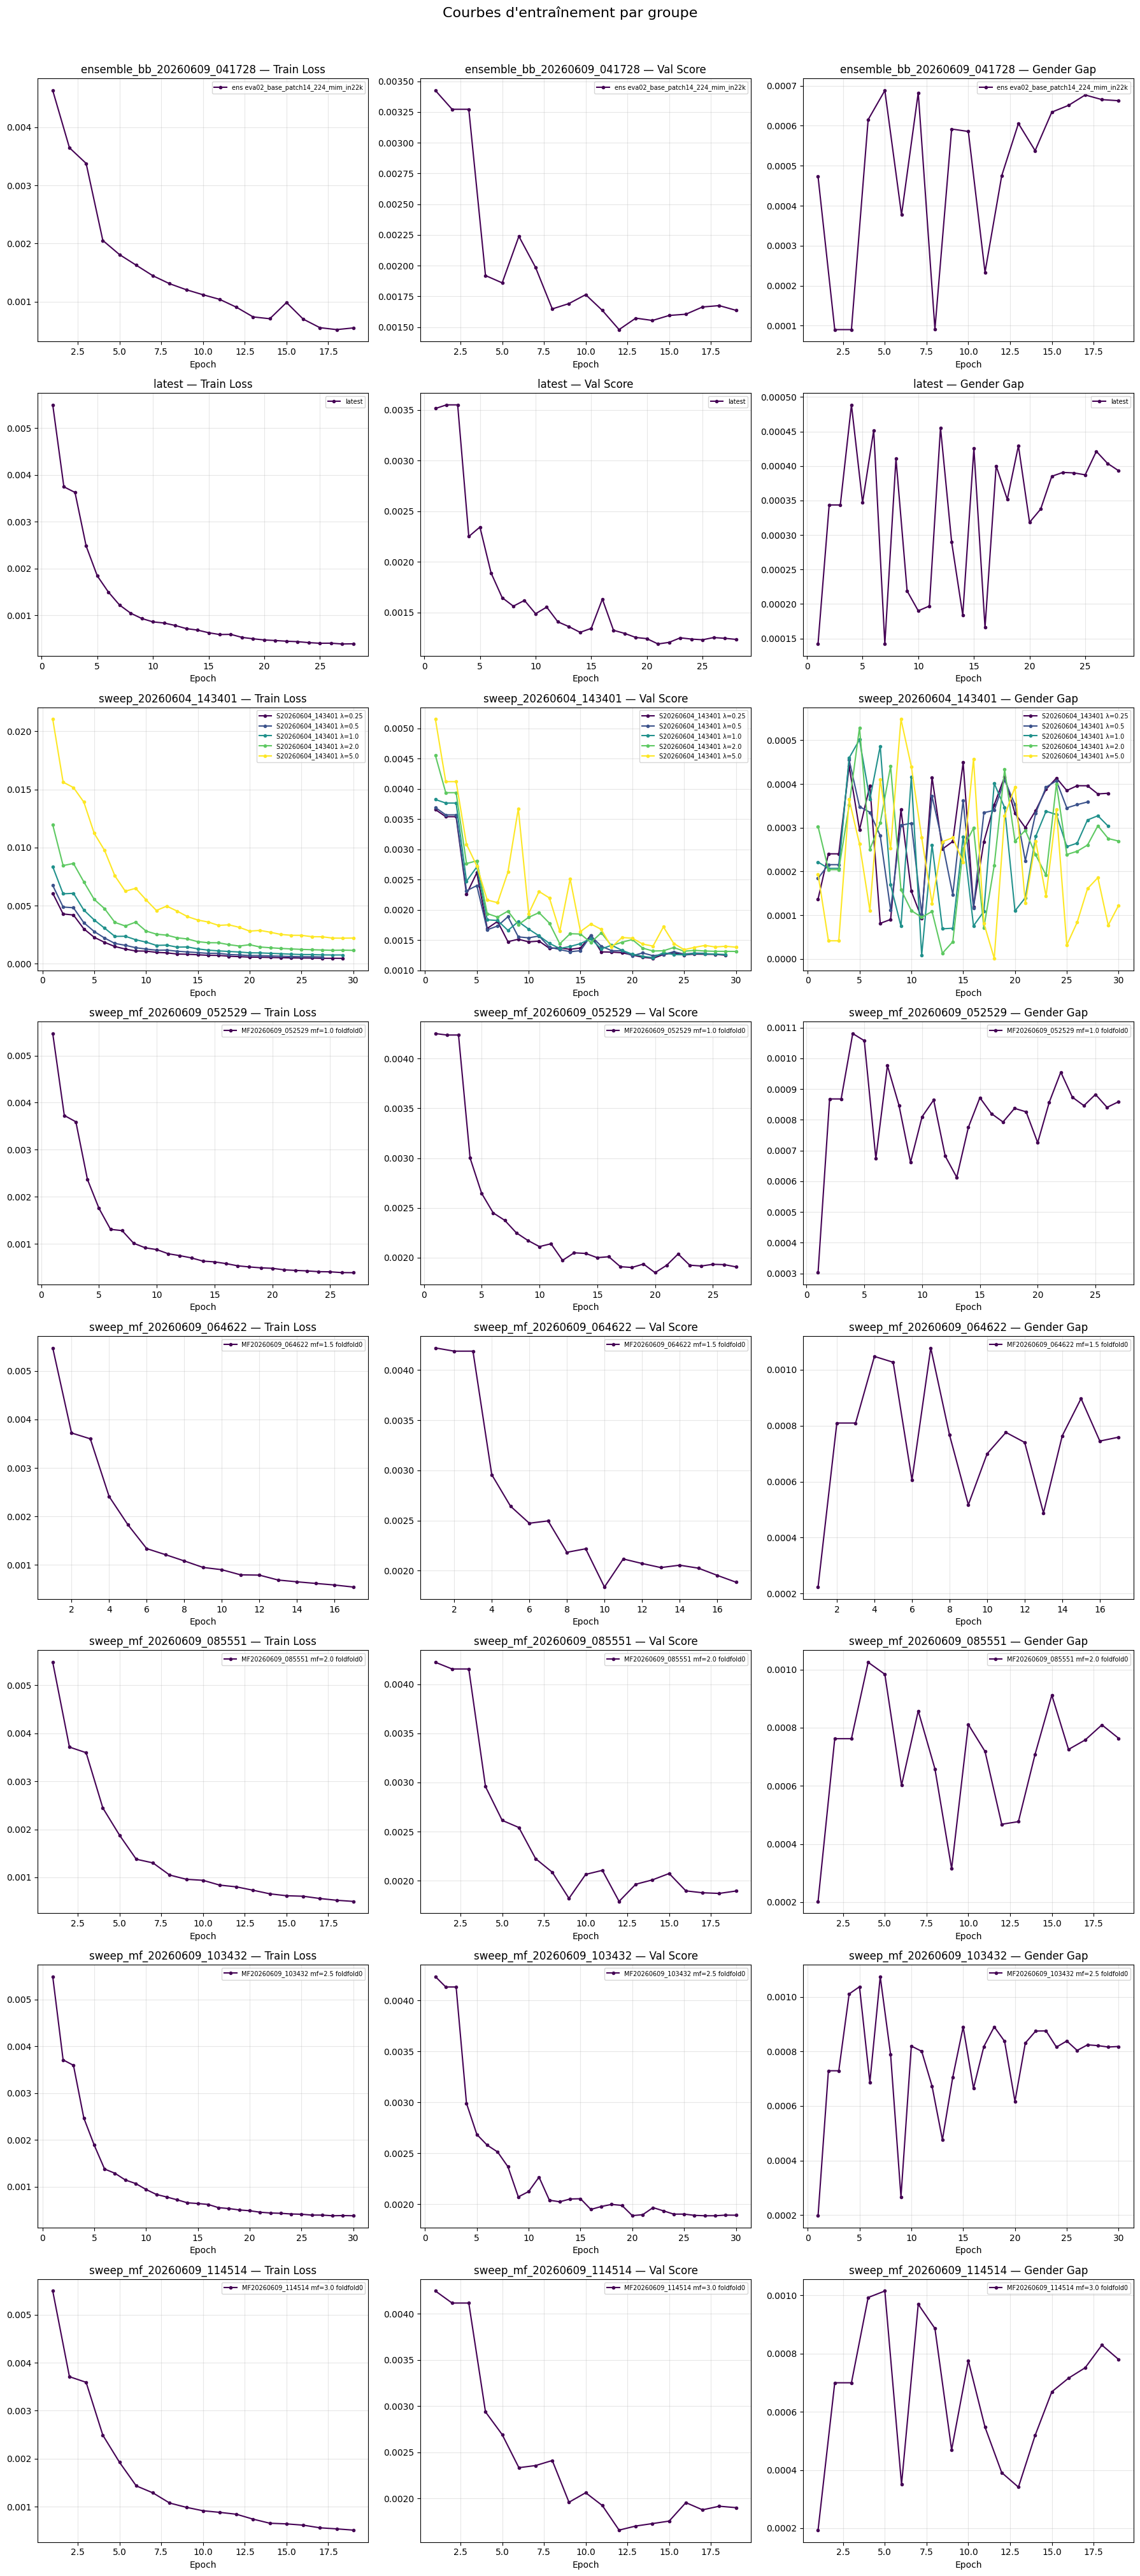

In [6]:
n_groups = len(groups)
fig, axes_grid = plt.subplots(n_groups, 3, figsize=(18, 5 * n_groups), squeeze=False)

for g_idx, group_name in enumerate(sorted(groups)):
    group_runs = [r for r in all_runs if r["group"] == group_name]
    cmap_g = cm.viridis(np.linspace(0, 1, max(1, len(group_runs))))
    
    for i, run in enumerate(sorted(group_runs, key=lambda r: r["label"])):
        h = run["history"]
        c = cmap_g[i]
        label = run["label"]
        
        axes_grid[g_idx, 0].plot(h["epoch"], h["train_loss"], "o-", color=c, label=label, markersize=3)
        axes_grid[g_idx, 1].plot(h["epoch"], h["val_score"], "o-", color=c, label=label, markersize=3)
        gap = [abs(f - m) for f, m in zip(h["err_f"], h["err_m"])]
        axes_grid[g_idx, 2].plot(h["epoch"], gap, "o-", color=c, label=label, markersize=3)
    
    axes_grid[g_idx, 0].set_title(f"{group_name} — Train Loss")
    axes_grid[g_idx, 0].set_xlabel("Epoch")
    axes_grid[g_idx, 0].legend(fontsize=7)
    axes_grid[g_idx, 0].grid(True, alpha=0.3)
    
    axes_grid[g_idx, 1].set_title(f"{group_name} — Val Score")
    axes_grid[g_idx, 1].set_xlabel("Epoch")
    axes_grid[g_idx, 1].legend(fontsize=7)
    axes_grid[g_idx, 1].grid(True, alpha=0.3)
    
    axes_grid[g_idx, 2].set_title(f"{group_name} — Gender Gap")
    axes_grid[g_idx, 2].set_xlabel("Epoch")
    axes_grid[g_idx, 2].legend(fontsize=7)
    axes_grid[g_idx, 2].grid(True, alpha=0.3)

plt.suptitle("Courbes d'entraînement par groupe", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 6. Tableau récapitulatif final

In [7]:
df_display = df.sort_values("best_score").reset_index(drop=True)
df_display.index = df_display.index + 1  # rank from 1
df_display.index.name = "Rank"

styled = (df_display[["label", "source", "best_score", "best_err_f", "best_err_m", "best_gap", "best_epoch", "num_epochs"]]
    .rename(columns={
        "label": "Modèle", "source": "Type", "best_score": "Score ↓",
        "best_err_f": "Err_F", "best_err_m": "Err_M", "best_gap": "Gap",
        "best_epoch": "Best Epoch", "num_epochs": "Total Epochs"
    })
    .style
    .format({"Score ↓": "{:.6f}", "Err_F": "{:.6f}", "Err_M": "{:.6f}", "Gap": "{:.6f}"})
    .highlight_min(subset=["Score ↓"], color="#2ecc71")
    .highlight_min(subset=["Gap"], color="#d4efdf")
)
styled

,Modèle,Type,Score ↓,Err_F,Err_M,Gap,Best Epoch,Total Epochs
Rank,,,,,,,,
1,latest,other,0.001187,0.000681,0.001019,0.000338,21,28
2,S20260604_143401 λ=0.25,sweep_lambda,0.001197,0.000688,0.001028,0.000339,22,29
3,S20260604_143401 λ=1.0,sweep_lambda,0.001208,0.000788,0.001068,0.000280,22,29
4,S20260604_143401 λ=0.5,sweep_lambda,0.001240,0.000711,0.001064,0.000353,20,27
5,S20260604_143401 λ=2.0,sweep_lambda,0.001312,0.000907,0.001177,0.000269,30,30
6,S20260604_143401 λ=5.0,sweep_lambda,0.001340,0.001292,0.001324,0.000032,25,30
7,ens eva02_base_patch14_224_mim_in22k,ensemble_bb,0.001479,0.000767,0.001242,0.000475,12,19
8,MF20260609_114514 mf=3.0 foldfold0,sweep_mf,0.001657,0.001070,0.001461,0.000391,12,19
9,MF20260609_085551 mf=2.0 foldfold0,sweep_mf,0.001790,0.001088,0.001556,0.000468,12,19
